# Runtime analytics for all 5,000-trial ACLib runs

This notebook auto-discovers every run below `experiments/aclib` whose saved SMAC scenario has `n_trials == 5000`. It can be rerun while jobs are active. Runtime is reconstructed from the `starttime` and `endtime` fields in `runhistory.json`; the target-function `time` field alone is **not** the runtime of SMAC because it excludes model fitting, acquisition optimization, intensification, and bookkeeping.

The primary elapsed time is:

- **observed optimizer span**: last recorded evaluation end minus first recorded evaluation start. Inter-trial time is included because SMAC performs model training, acquisition optimization, intensification, callbacks, and checkpointing between target evaluations.
- **long inter-trial time**: the sum of individual gaps longer than `LONG_GAP_SECONDS` (300 seconds by default). This is reported diagnostically but is not subtracted: a long gap is optimizer work unless scheduler accounting independently proves that the process was stopped.

The first/last timestamps omit setup before the first evaluation and shutdown after the last evaluation. Active-job figures are snapshots of the last runhistory flush.

In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

TARGET_TRIALS = 5000
WINDOW_TRIALS = 500
LONG_GAP_SECONDS = 300
DEPTHS = [5, 10, 15, 20, 30]

def find_aclib_root():
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        if parent.name == 'aclib' and (parent / 'cplex_rcw_surrogate').exists():
            return parent
        candidate = parent / 'experiments' / 'aclib'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not locate experiments/aclib from the current working directory.')

ACLIB_ROOT = find_aclib_root()
print('ACLib root:', ACLIB_ROOT)
plt.style.use('seaborn-v0_8-whitegrid')

ACLib root: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib


## Load the current run snapshots

The loader retries files that may be replaced while an active job is checkpointing. A 500-trial window is measured from the previous window endpoint, so its duration includes the SMAC work performed between evaluations. The first window starts at the first target evaluation.

In [2]:
def read_json_retry(path, attempts=5, delay=0.1):
    error = None
    for _ in range(attempts):
        try:
            with path.open() as fh:
                return json.load(fh)
        except (json.JSONDecodeError, OSError) as exc:
            error = exc
            time.sleep(delay)
    raise error

def safe_json(path, default=None):
    if not path.exists():
        return {} if default is None else default
    try:
        return read_json_retry(path)
    except (json.JSONDecodeError, OSError):
        return {} if default is None else default

def discover_runtime_data(root=ACLIB_ROOT):
    run_records, cumulative_records, window_records = [], [], []
    for scenario_path in sorted(root.glob('**/results/depth_*/*/scenario.json')):
        scenario = safe_json(scenario_path)
        if scenario.get('n_trials') != TARGET_TRIALS:
            continue
        run_dir = scenario_path.parent
        runhistory = safe_json(run_dir / 'runhistory.json', {'data': []})
        rows = runhistory.get('data', [])
        metadata = safe_json(run_dir / 'run_metadata.json')
        completion = safe_json(run_dir / 'completed.json')
        relative = run_dir.relative_to(root)
        results_index = relative.parts.index('results')
        experiment = '/'.join(relative.parts[:results_index])
        depth = int(metadata.get('depth', relative.parts[results_index + 1].split('_')[-1]))
        seed = int(metadata.get('smac_seed', relative.parts[results_index + 2]))
        benchmark = metadata.get('benchmark', relative.parts[0].removesuffix('_surrogate'))
        display_name = metadata.get('display_name', benchmark.replace('_', ' ').title())

        valid = [r for r in rows if r.get('starttime') is not None and r.get('endtime') is not None]
        starts = np.asarray([float(r['starttime']) for r in valid])
        ends = np.asarray([float(r['endtime']) for r in valid])
        target_times = np.asarray([float(r.get('time') or 0.0) for r in valid])
        n = len(valid)
        if n:
            wall_seconds = float(ends[-1] - starts[0])
            gaps = np.maximum(0.0, starts[1:] - ends[:-1])
            long_gaps = gaps[gaps > LONG_GAP_SECONDS]
            long_intertrial_seconds = float(long_gaps.sum())
            active_seconds = wall_seconds
            rate_denominator = max(n - 1, 1)
            sec_per_trial = active_seconds / rate_denominator
            recent_start = max(0, n - WINDOW_TRIALS)
            recent_count = n - recent_start
            recent_seconds = float(ends[-1] - starts[recent_start])
            recent_sec_per_trial = recent_seconds / max(recent_count - 1, 1)
            remaining = max(0, TARGET_TRIALS - n)
            eta_hours = remaining * recent_sec_per_trial / 3600
            projected_active_hours = (active_seconds + remaining * recent_sec_per_trial) / 3600
            target_seconds = float(target_times.sum())
        else:
            wall_seconds = long_intertrial_seconds = active_seconds = target_seconds = np.nan
            sec_per_trial = recent_sec_per_trial = eta_hours = projected_active_hours = np.nan
            gaps = np.asarray([])

        state = completion.get('state', 'running' if n else 'not started')
        complete = state == 'complete' and n >= TARGET_TRIALS
        run_id = f'{experiment}/depth_{depth}/seed_{seed}'
        run_records.append({
            'run_id': run_id, 'experiment': experiment, 'benchmark': benchmark,
            'display_name': display_name, 'depth': depth, 'seed': seed,
            'state': 'complete' if complete else state, 'complete': complete,
            'trials': n, 'target_trials': TARGET_TRIALS, 'progress_pct': 100 * n / TARGET_TRIALS,
            'wall_hours': wall_seconds / 3600, 'active_hours': active_seconds / 3600,
            'long_intertrial_hours': long_intertrial_seconds / 3600,
            'long_gap_count': int(np.sum(gaps > LONG_GAP_SECONDS)) if n else 0,
            'max_gap_minutes': float(gaps.max() / 60) if len(gaps) else 0.0,
            'seconds_per_trial': sec_per_trial,
            'trials_per_hour': 3600 / sec_per_trial if sec_per_trial > 0 else np.nan,
            'recent_seconds_per_trial': recent_sec_per_trial,
            'eta_hours': eta_hours, 'projected_active_hours': projected_active_hours,
            'target_eval_seconds': target_seconds,
            'target_eval_share_pct': 100 * target_seconds / active_seconds if active_seconds > 0 else np.nan,
        })

        if n:
            elapsed = ends - starts[0]
            chosen = sorted(set(range(0, n, 100)) | {n - 1})
            for i in chosen:
                cumulative_records.append({
                    'run_id': run_id, 'experiment': experiment, 'display_name': display_name,
                    'depth': depth, 'seed': seed, 'trial': i + 1,
                    'active_hours': elapsed[i] / 3600,
                })
            previous_end = starts[0]
            for stop in range(WINDOW_TRIALS, n + 1, WINDOW_TRIALS):
                raw_duration = ends[stop - 1] - previous_end
                lo = max(0, stop - WINDOW_TRIALS)
                duration = raw_duration
                window_records.append({
                    'run_id': run_id, 'experiment': experiment, 'display_name': display_name,
                    'depth': depth, 'seed': seed, 'window_end': stop,
                    'seconds_per_trial': duration / WINDOW_TRIALS,
                })
                previous_end = ends[stop - 1]

    return pd.DataFrame(run_records), pd.DataFrame(cumulative_records), pd.DataFrame(window_records)

runs, cumulative, windows = discover_runtime_data()
print(f'Loaded {len(runs)} runs from {runs.experiment.nunique()} experiments at {pd.Timestamp.now()}')

Loaded 75 runs from 5 experiments at 2026-07-28 00:52:01.437010


## Coverage and current progress

This table answers which 5,000-trial experiments were discovered, how many seed/depth runs have finished, and how much of the complete workload is present in the saved run histories. A run marked active may have advanced beyond this snapshot if its latest checkpoint has not yet been written.

In [3]:
coverage = (runs.groupby(['experiment', 'display_name'], as_index=False)
    .agg(runs=('run_id', 'size'), completed=('complete', 'sum'),
         saved_trials=('trials', 'sum'), min_trials=('trials', 'min'), max_trials=('trials', 'max')))
coverage['total_trials'] = coverage['runs'] * TARGET_TRIALS
coverage['progress_pct'] = 100 * coverage['saved_trials'] / coverage['total_trials']
display(coverage[['experiment', 'runs', 'completed', 'min_trials', 'max_trials', 'progress_pct']]
        .style.format({'progress_pct': '{:.1f}%'}))

status = runs[['display_name', 'depth', 'seed', 'state', 'trials', 'progress_pct',
               'wall_hours', 'active_hours', 'long_intertrial_hours', 'long_gap_count',
               'seconds_per_trial', 'recent_seconds_per_trial']].sort_values(['display_name', 'depth', 'seed'])
display(status.style.format({
    'progress_pct': '{:.1f}%', 'wall_hours': '{:.2f}', 'active_hours': '{:.2f}',
    'long_intertrial_hours': '{:.2f}', 'seconds_per_trial': '{:.2f}',
    'recent_seconds_per_trial': '{:.2f}'
}))

,experiment,runs,completed,min_trials,max_trials,progress_pct
0,clasp_queens_surrogate/01_initial_cq,15,15,5000,5000,100.0%
1,clasp_weighted-sequence_surrogate/01_initial_cw,15,15,5000,5000,100.0%
2,cplex_rcw_surrogate/01_initial_cr,15,1,2101,5000,73.7%
3,lingeling_circuitfuzz_surrogate/01_initial_lc,15,0,284,932,8.1%
4,lpg_zenotravel_surrogate/01_initial_lz,15,4,1462,5000,56.9%


,display_name,depth,seed,state,trials,progress_pct,wall_hours,active_hours,interruption_hours,long_gap_count,seconds_per_trial,recent_seconds_per_trial
42,CPLEX RCW,5,0,running,2813,56.3%,23.54,0.19,23.35,84,0.24,0.27
43,CPLEX RCW,5,1,running,2512,50.2%,23.48,0.19,23.29,91,0.27,0.25
44,CPLEX RCW,5,2,running,2101,42.0%,23.56,0.15,23.40,88,0.26,0.31
30,CPLEX RCW,10,0,running,4385,87.7%,23.45,0.18,23.27,60,0.14,0.23
31,CPLEX RCW,10,1,running,2909,58.2%,23.07,0.09,22.98,47,0.11,0.18
32,CPLEX RCW,10,2,running,4189,83.8%,23.44,0.23,23.22,62,0.20,0.27
33,CPLEX RCW,15,0,running,3409,68.2%,23.21,0.12,23.09,55,0.12,0.23
34,CPLEX RCW,15,1,running,3580,71.6%,23.50,0.13,23.37,59,0.13,0.25
35,CPLEX RCW,15,2,running,4251,85.0%,23.34,0.22,23.12,58,0.19,0.25
36,CPLEX RCW,20,0,running,3806,76.1%,23.53,0.15,23.38,59,0.14,0.22


## Benchmark-level completion summary

For a benchmark where all depth/seed runs finished, `mean_finish_hours` is the arithmetic mean observed optimizer runtime of all 15 complete runs. For a benchmark that has not fully finished, `mean_saved_trials` and `mean_progress_pct` average the current saved progress across all of its depth/seed runs. Inapplicable cells are intentionally left blank.

In [4]:
benchmark_completion = []
for name, group in runs.groupby('display_name', sort=True):
    all_finished = bool(group.complete.all())
    benchmark_completion.append({
        'benchmark': name,
        'status': 'all runs finished' if all_finished else 'still running',
        'finished_runs': int(group.complete.sum()),
        'total_runs': len(group),
        'mean_finish_hours': group.active_hours.mean() if all_finished else np.nan,
        'mean_saved_trials': np.nan if all_finished else group.trials.mean(),
        'mean_progress_pct': np.nan if all_finished else group.progress_pct.mean(),
    })

benchmark_completion = pd.DataFrame(benchmark_completion).set_index('benchmark')
display(benchmark_completion.style.format({
    'mean_finish_hours': '{:.2f}',
    'mean_saved_trials': '{:.1f}',
    'mean_progress_pct': '{:.1f}%'
}, na_rep='—'))

,status,finished_runs,total_runs,mean_finish_hours,mean_saved_trials,mean_progress_pct
benchmark,,,,,,
CPLEX RCW,still running,1,15,—,3687.0,73.7%
Clasp Queens,all runs finished,15,15,3.53,—,—
Clasp weighted-sequence,all runs finished,15,15,2.61,—,—
LPG Zenotravel,still running,4,15,—,2843.7,56.9%
Lingeling Circuitfuzz,still running,0,15,—,405.7,8.1%


## Completed-run duration by benchmark

Each point is one fully completed 5,000-trial depth/seed run. The horizontal mark is the benchmark median. Runtime includes all time between target evaluations because this is where SMAC trains its model and optimizes the acquisition function.

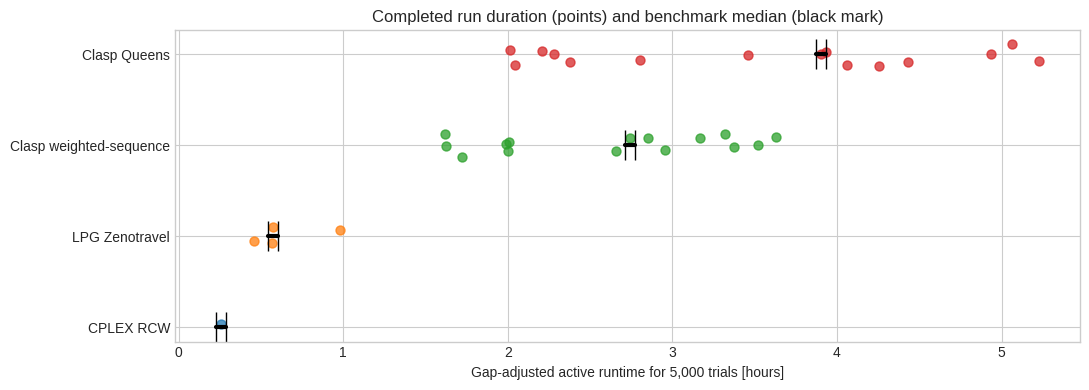

,completed_runs,median_active_hours,min_active_hours,max_active_hours,median_trials_per_hour,median_wall_hours
display_name,,,,,,
CPLEX RCW,1,0.26,0.26,0.26,19408.22,22.24
LPG Zenotravel,4,0.57,0.46,0.98,8741.10,18.03
Clasp weighted-sequence,15,2.74,1.62,3.63,1823.69,2.74
Clasp Queens,15,3.90,2.01,5.23,1281.19,3.90


In [5]:
completed = runs[runs.complete].copy()
if completed.empty:
    print('No completed 5,000-trial runs in the current snapshot.')
else:
    order = completed.groupby('display_name').active_hours.median().sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(11, max(4, 0.7 * len(order))))
    rng = np.random.default_rng(7)
    for y, name in enumerate(order):
        values = completed.loc[completed.display_name == name, 'active_hours'].to_numpy()
        ax.scatter(values, y + rng.uniform(-0.13, 0.13, len(values)), alpha=.75, s=42)
        ax.plot([np.median(values) - .03, np.median(values) + .03], [y, y], marker='|',
                markersize=22, color='black', linewidth=3)
    ax.set_yticks(range(len(order)), order)
    ax.set_xlabel('Observed optimizer runtime for 5,000 trials [hours]')
    ax.set_title('Completed run duration (points) and benchmark median (black mark)')
    plt.tight_layout(); plt.show()

    completed_summary = completed.groupby('display_name').agg(
        completed_runs=('run_id', 'size'), median_active_hours=('active_hours', 'median'),
        min_active_hours=('active_hours', 'min'), max_active_hours=('active_hours', 'max'),
        median_trials_per_hour=('trials_per_hour', 'median'),
        median_wall_hours=('wall_hours', 'median')).sort_values('median_active_hours')
    display(completed_summary.style.format('{:.2f}', subset=completed_summary.columns[1:]))

## Speed as a function of RF depth

Seconds per trial includes the full SMAC loop and excludes only detected gaps longer than five minutes. Every point is the observed rate of one seed, using all trials currently saved; connected median lines summarize the depth effect. Partial and completed runs are both included because a partial run still gives an observed throughput, but rates can worsen later as the runhistory and RF training set grow.

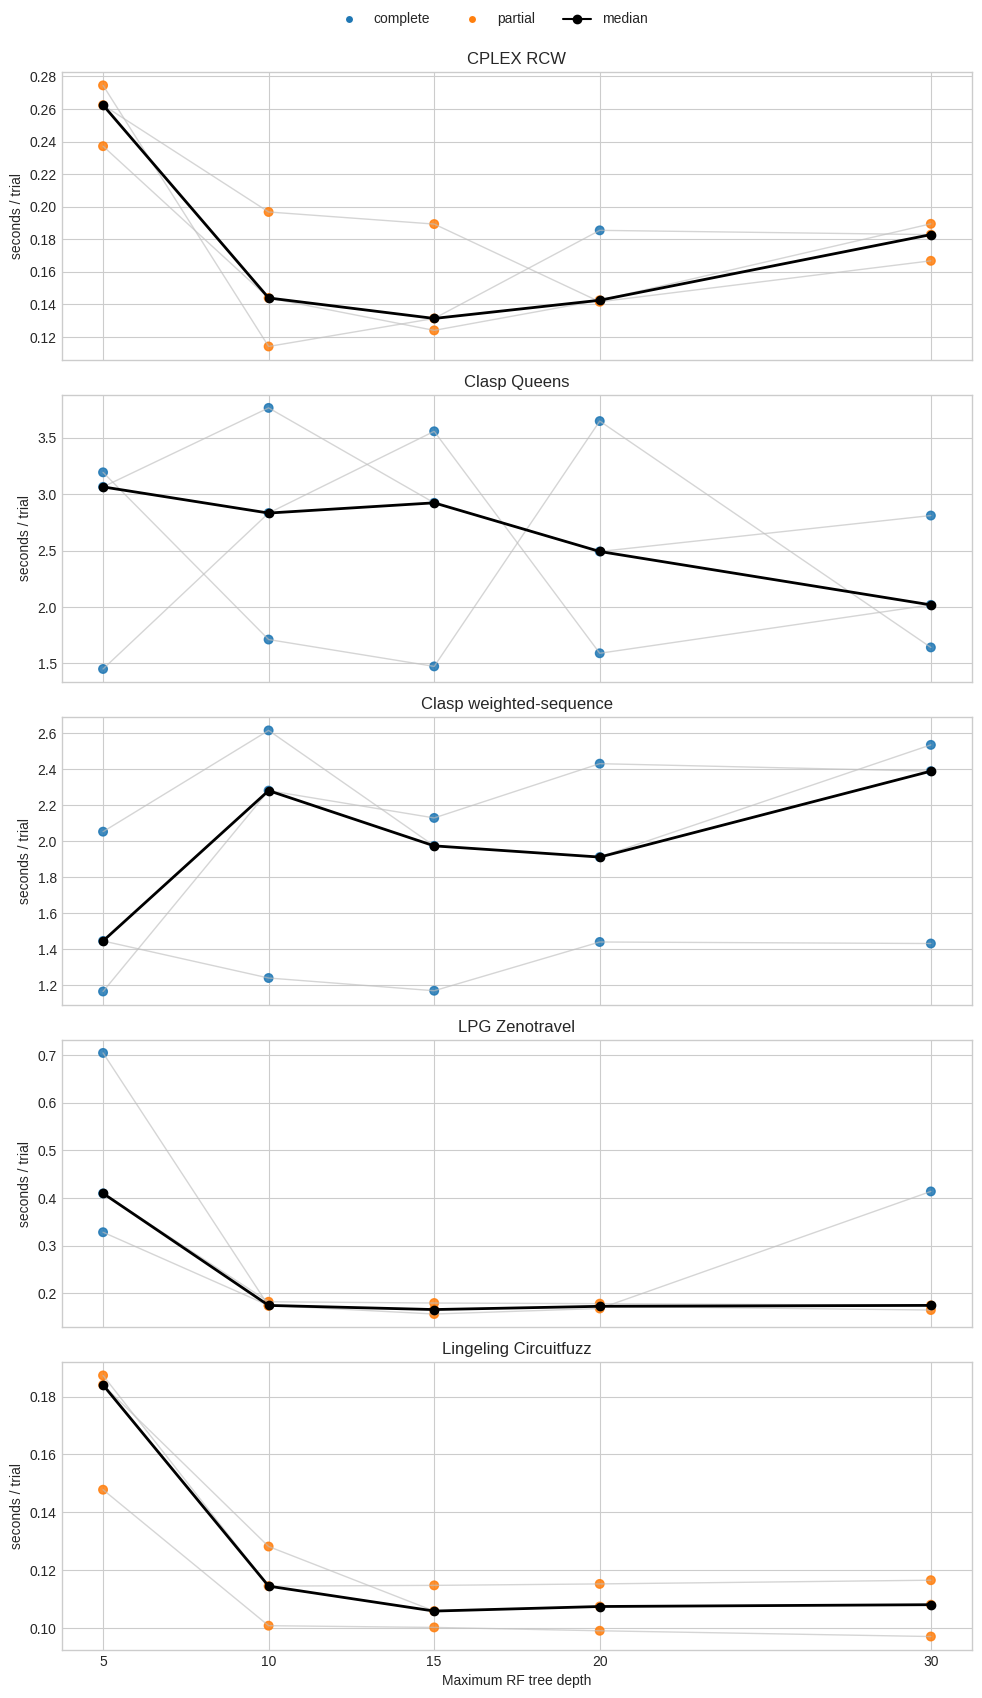

In [6]:
names = sorted(runs.display_name.unique())
fig, axes = plt.subplots(len(names), 1, figsize=(10, 3.4 * len(names)), sharex=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, names):
    sub = runs[runs.display_name == name]
    for seed, seed_data in sub.groupby('seed'):
        seed_data = seed_data.sort_values('depth')
        ax.plot(seed_data.depth, seed_data.seconds_per_trial, color='0.75', alpha=.65, linewidth=1)
        ax.scatter(seed_data.depth, seed_data.seconds_per_trial,
                   c=np.where(seed_data.complete, 'tab:blue', 'tab:orange'), s=38, alpha=.85)
    median = sub.groupby('depth').seconds_per_trial.median().reindex(DEPTHS)
    ax.plot(median.index, median.values, color='black', marker='o', linewidth=2, label='median')
    ax.set_ylabel('seconds / trial')
    ax.set_title(name)
axes[-1].set_xlabel('Maximum RF tree depth')
axes[-1].set_xticks(DEPTHS)
fig.legend(handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:blue', label='complete'),
                    Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:orange', label='partial'),
                    Line2D([0],[0], color='black', marker='o', label='median')],
           loc='upper center', ncol=3)
plt.tight_layout(rect=(0, 0, 1, .98)); plt.show()

## Cumulative runtime trajectories

These curves show how many observed optimizer hours SMAC needed to reach each trial. One panel is produced per benchmark; color identifies RF depth and the three seed curves share that color. Increasing slope means later trials are becoming slower. Curves ending before trial 5,000 are unfinished snapshots.

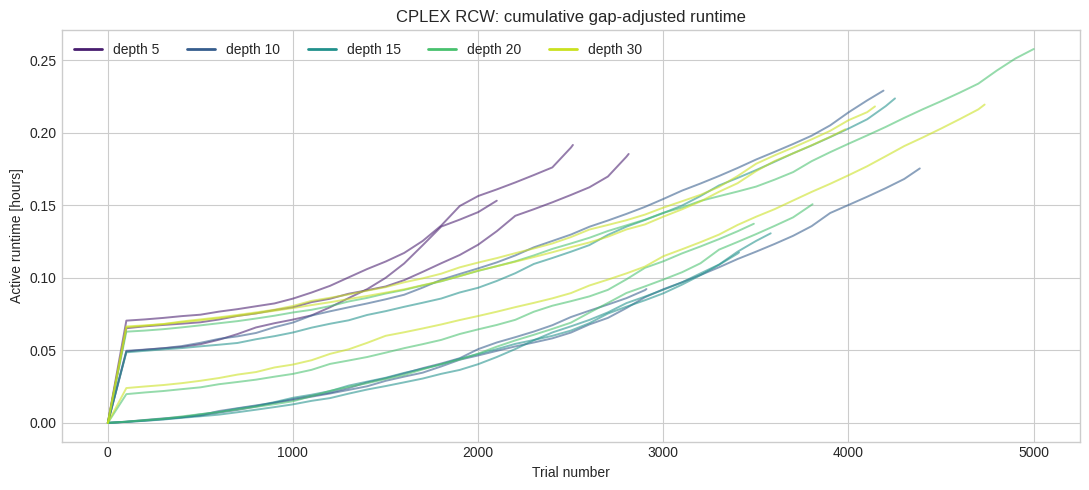

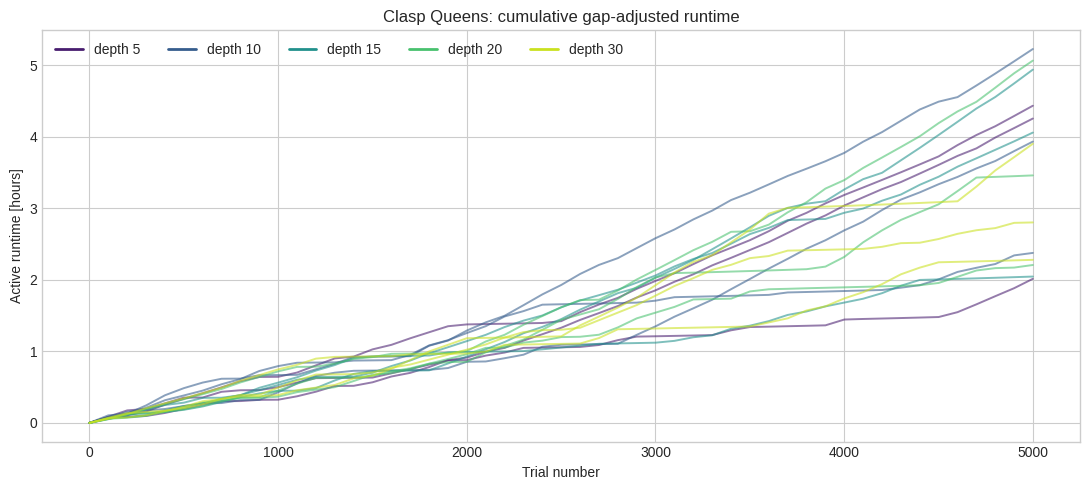

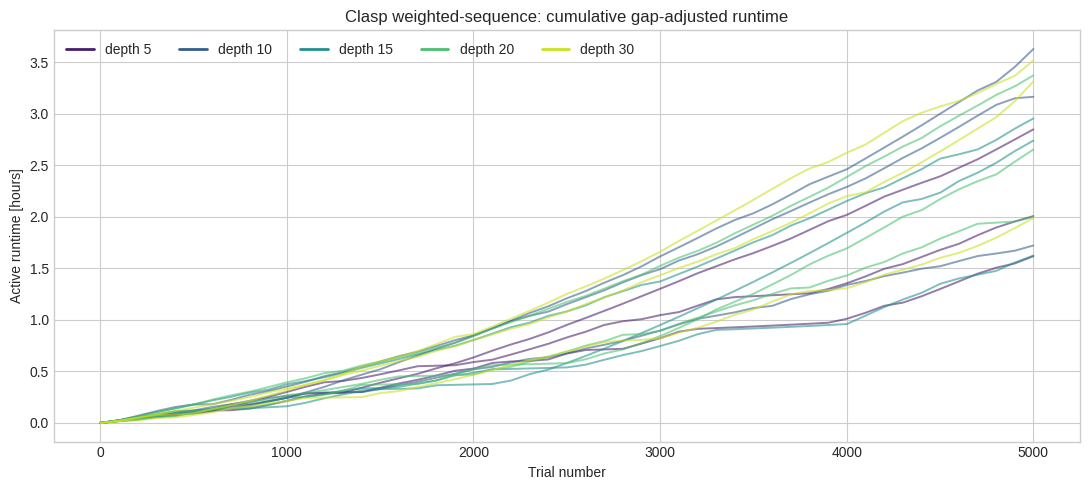

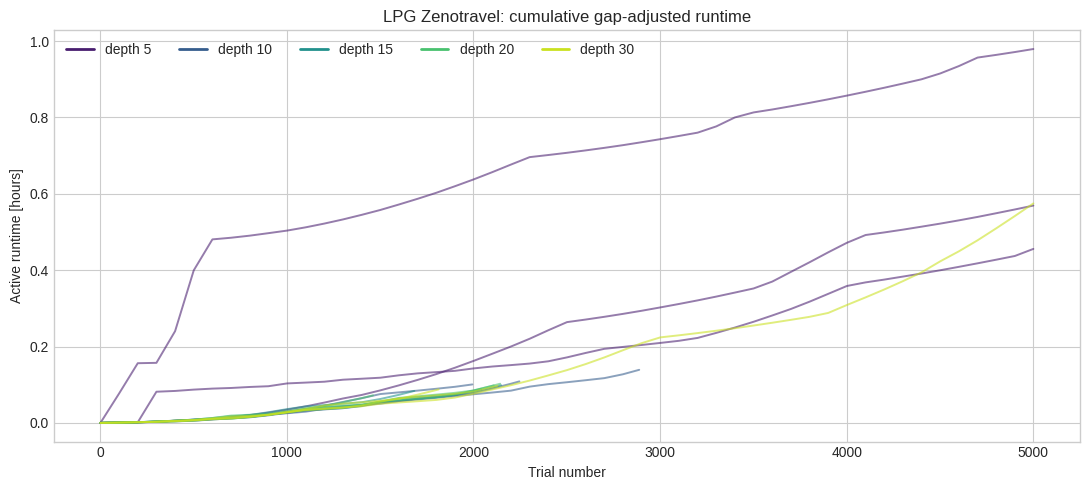

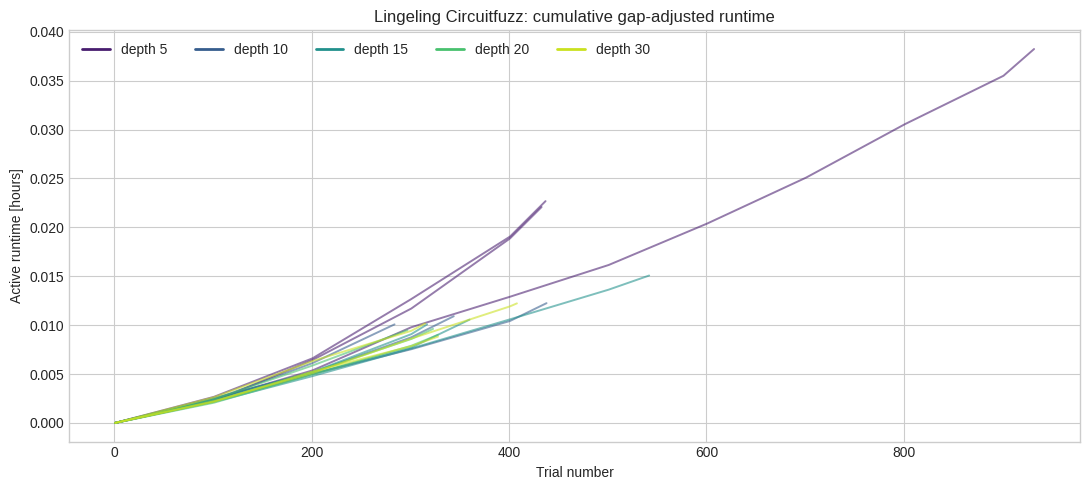

In [7]:
colors = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(.08, .92, len(DEPTHS)))))
for name in names:
    fig, ax = plt.subplots(figsize=(11, 5))
    sub = cumulative[cumulative.display_name == name]
    for (depth, seed), curve in sub.groupby(['depth', 'seed']):
        ax.plot(curve.trial, curve.active_hours, color=colors.get(depth), alpha=.58, linewidth=1.4)
    ax.set(title=f'{name}: cumulative optimizer runtime', xlabel='Trial number', ylabel='Observed runtime [hours]')
    ax.legend(handles=[Line2D([0],[0], color=colors[d], lw=2, label=f'depth {d}') for d in DEPTHS],
              ncol=len(DEPTHS), loc='upper left')
    plt.tight_layout(); plt.show()

## Slowdown over successive 500-trial windows

For every complete 500-trial block, the line shows the median seconds per trial across the three SMAC seeds at a fixed depth. This directly reveals whether SMAC slows as more observations accumulate. An unfinished final block is omitted because comparing unequal window sizes would distort the rate.

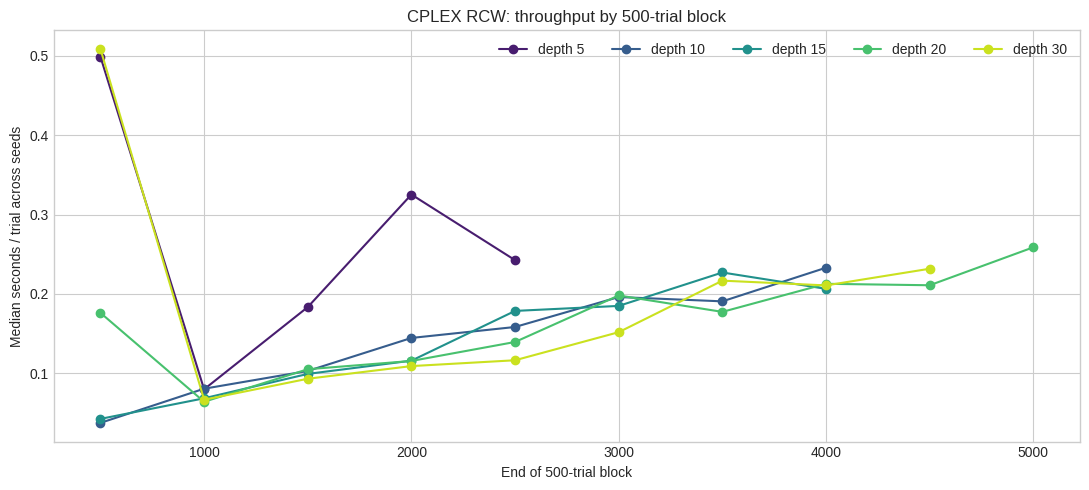

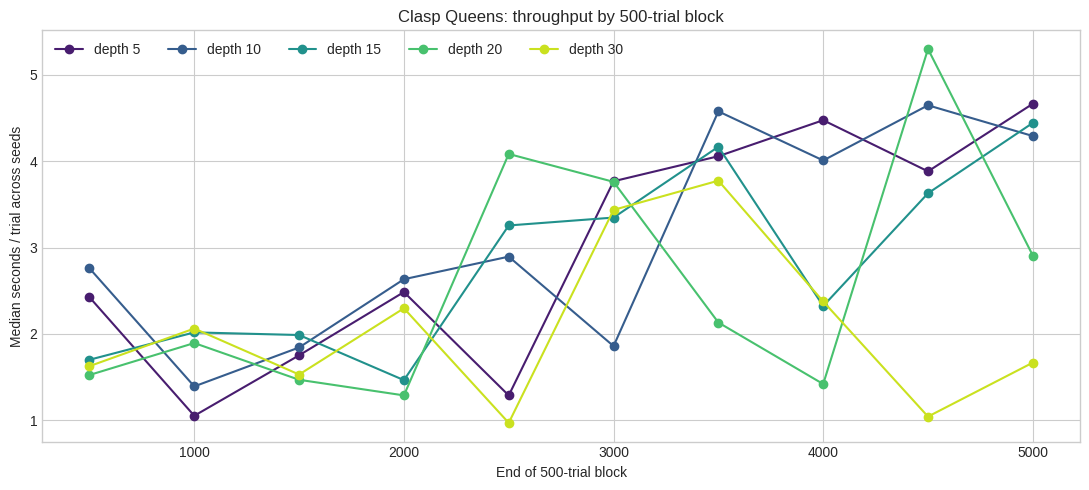

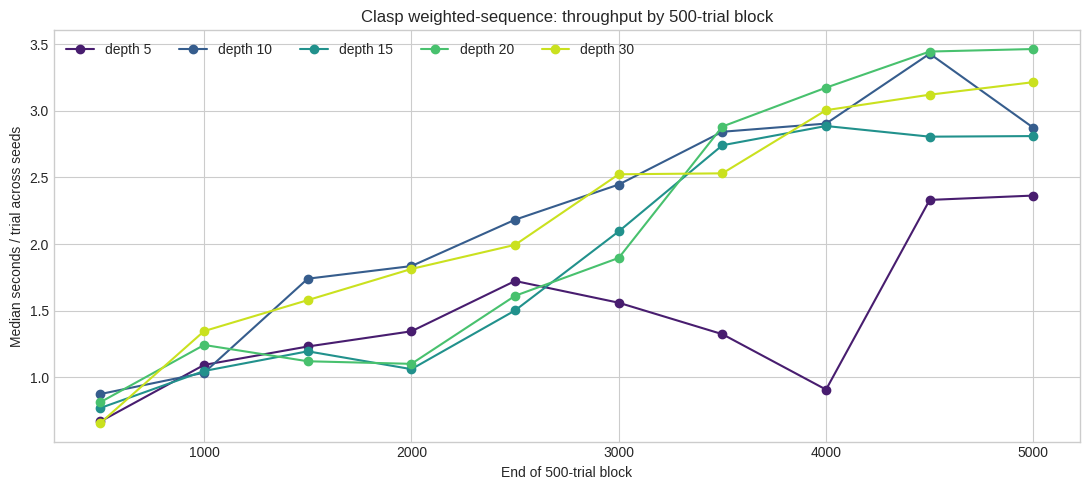

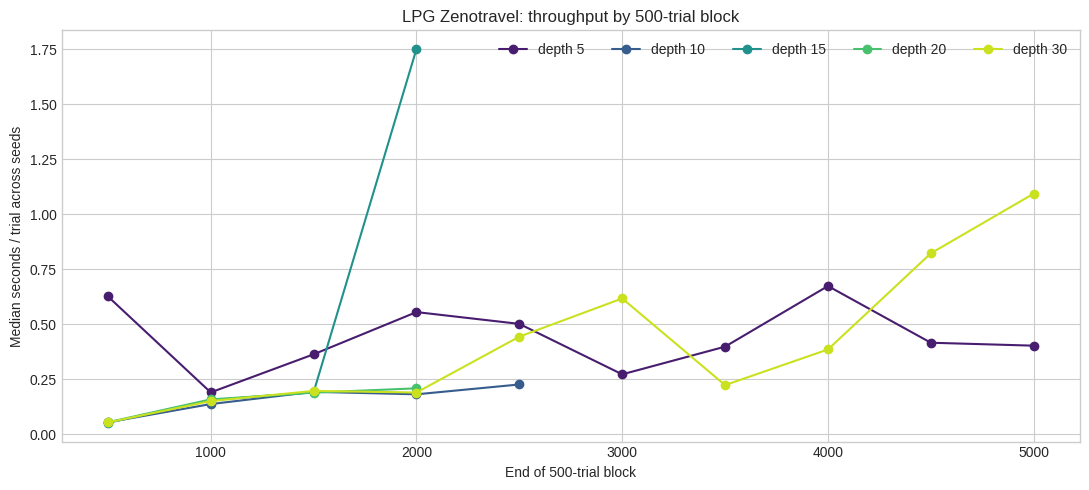

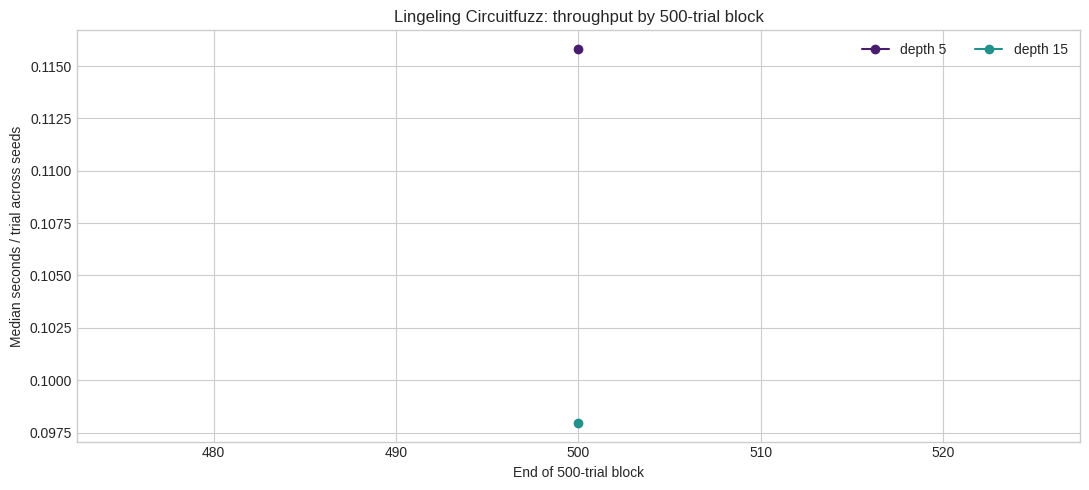

In [8]:
for name in names:
    fig, ax = plt.subplots(figsize=(11, 5))
    sub = windows[windows.display_name == name]
    med = sub.groupby(['depth', 'window_end'], as_index=False).seconds_per_trial.median()
    for depth, curve in med.groupby('depth'):
        ax.plot(curve.window_end, curve.seconds_per_trial, color=colors.get(depth),
                marker='o', label=f'depth {depth}')
    ax.set(title=f'{name}: throughput by 500-trial block', xlabel='End of 500-trial block',
           ylabel='Median seconds / trial across seeds')
    ax.legend(ncol=len(DEPTHS)); plt.tight_layout(); plt.show()

## ETA for unfinished runs

ETA extrapolates the observed rate of the most recent 500 saved trials. It is a workload estimate, not a completion timestamp: scheduler queue time, future interruptions, and progressive SMAC slowdown are unknown. `projected_active_hours` combines optimizer time already observed with that recent-rate estimate.

In [9]:
unfinished = runs[~runs.complete].copy().sort_values(['display_name', 'depth', 'seed'])
eta_columns = ['display_name', 'depth', 'seed', 'trials', 'progress_pct', 'active_hours',
               'recent_seconds_per_trial', 'eta_hours', 'projected_active_hours',
               'long_intertrial_hours', 'max_gap_minutes']
if unfinished.empty:
    print('All discovered 5,000-trial runs are complete.')
else:
    display(unfinished[eta_columns].style.format({
        'progress_pct': '{:.1f}%', 'active_hours': '{:.2f}',
        'recent_seconds_per_trial': '{:.2f}', 'eta_hours': '{:.1f}',
        'projected_active_hours': '{:.1f}', 'long_intertrial_hours': '{:.2f}',
        'max_gap_minutes': '{:.1f}'
    }))

,display_name,depth,seed,trials,progress_pct,active_hours,recent_seconds_per_trial,eta_hours,projected_active_hours,interruption_hours,max_gap_minutes
42,CPLEX RCW,5,0,2813,56.3%,0.19,0.27,0.2,0.3,23.35,22.2
43,CPLEX RCW,5,1,2512,50.2%,0.19,0.25,0.2,0.4,23.29,23.2
44,CPLEX RCW,5,2,2101,42.0%,0.15,0.31,0.3,0.4,23.40,27.0
30,CPLEX RCW,10,0,4385,87.7%,0.18,0.23,0.0,0.2,23.27,31.7
31,CPLEX RCW,10,1,2909,58.2%,0.09,0.18,0.1,0.2,22.98,53.0
32,CPLEX RCW,10,2,4189,83.8%,0.23,0.27,0.1,0.3,23.22,31.4
33,CPLEX RCW,15,0,3409,68.2%,0.12,0.23,0.1,0.2,23.09,40.0
34,CPLEX RCW,15,1,3580,71.6%,0.13,0.25,0.1,0.2,23.37,32.9
35,CPLEX RCW,15,2,4251,85.0%,0.22,0.25,0.1,0.3,23.12,37.1
36,CPLEX RCW,20,0,3806,76.1%,0.15,0.22,0.1,0.2,23.38,31.3


## Where the time is spent

`target_eval_share_pct` compares the sum of target-function durations recorded by SMAC with the observed optimizer span. The remainder is not pure RF fitting time: it collectively contains model training, acquisition optimization, intensification logic, callbacks/telemetry, serialization, and other inter-trial work. A low target share therefore explains why timing only the ACLib surrogate calls greatly understates total runtime.

,runs,median_target_eval_share_pct,median_target_eval_seconds,median_active_hours,total_interruption_hours,runs_with_long_gaps
display_name,,,,,,
Lingeling Circuitfuzz,15,6.172%,2.4,0.01,332.93,15
LPG Zenotravel,15,3.656%,13.6,0.10,327.77,15
CPLEX RCW,15,1.194%,8.1,0.19,346.81,15
Clasp weighted-sequence,15,0.171%,16.5,2.74,0.00,0
Clasp Queens,15,0.155%,18.1,3.90,0.00,0


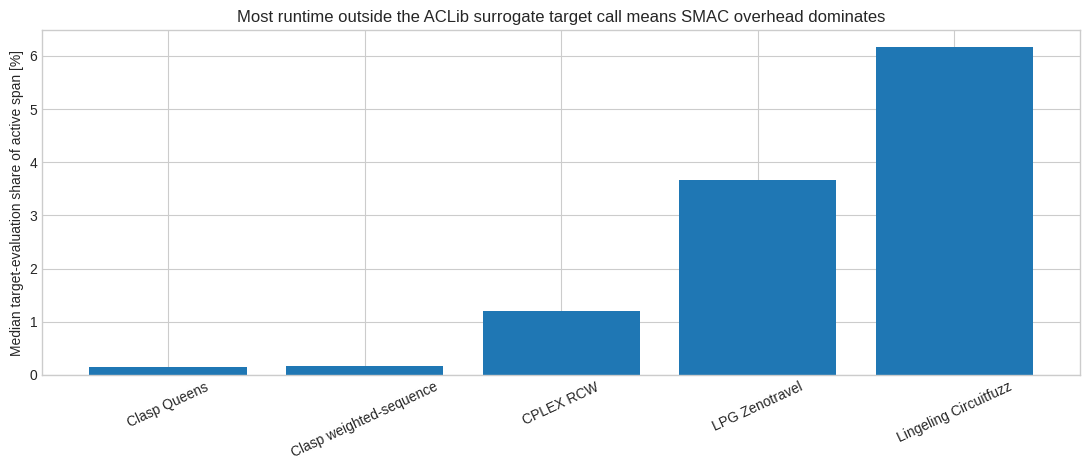

In [10]:
composition = runs.groupby('display_name').agg(
    runs=('run_id', 'size'), median_target_eval_share_pct=('target_eval_share_pct', 'median'),
    median_target_eval_seconds=('target_eval_seconds', 'median'),
    median_active_hours=('active_hours', 'median'),
    total_long_intertrial_hours=('long_intertrial_hours', 'sum'),
    runs_with_long_gaps=('long_gap_count', lambda x: int((x > 0).sum()))
).sort_values('median_active_hours')
display(composition.style.format({
    'median_target_eval_share_pct': '{:.3f}%', 'median_target_eval_seconds': '{:.1f}',
    'median_active_hours': '{:.2f}', 'total_long_intertrial_hours': '{:.2f}'
}))

fig, ax = plt.subplots(figsize=(11, 4.8))
plot_data = composition.sort_values('median_target_eval_share_pct')
ax.bar(plot_data.index, plot_data.median_target_eval_share_pct)
ax.set_ylabel('Median target-evaluation share of optimizer span [%]')
ax.set_title('Most runtime outside the ACLib surrogate target call means SMAC overhead dominates')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()